# Shoe Pair Matching - CNN Image Similarity

A convolutional neural network that classifies whether two shoes belong to the **same pair** or **different pairs**.

Two architectures are explored and compared:
- **CNN**: processes the concatenated image (448×224) directly
- **CNNChannel**: splits the image into two 224×224 halves and stacks them as 6-channel input

In [ ]:
import pandas
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import sys
from PIL import Image

def reload_functions():
  if 'ML_DL_Functions3' in sys.modules:
    del sys.modules['ML_DL_Functions3']
  functions_path = drive_path.replace(" ",r"\ ") + 'ML_DL_Functions3.py'
  !cp $functions_path .

## 1. Data

The dataset consists of shoe image pairs, each of size 448×224 (two 224×224 images stacked vertically).

Three splits are provided:
- `train`: used for training and validation
- `test_w`: women's shoes test set  
- `test_m`: men's shoes test set


In [ ]:
from google.colab import drive
drive_path = '/content/gdrive/MyDrive'
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### 1.1 Data Preprocessing

Images are loaded and preprocessed as follows:
- Alpha channel removed (RGBA -> RGB)
- Pixel values normalized from [0, 255] to [-0.5, 0.5]
- Data structured as `[N, 3, 2, 224, 224, 3]`, triplets of pairs per sample

In [ ]:
import glob

def get_sort_key(filename):
  """
  Sorting key function by:
    1. Numerical sorting of users and triplets (u001_2 comes before u001_10)
    2. 'Right' side comes before 'Left' side
  Returns (user_id, triplet_id, side_priority)
  """
  # filename format: u007_1_left_w.jpg
  parts = filename.split('_')
  # extract User ID (remove the 'u' part and convert to integer)
  user_id = int(parts[0][1:])
  # extract triplet ID
  triplet_id = int(parts[1])

  # 'right' side (0) appears before 'left' side (1)
  side = parts[2]
  # 'right'
  side_priority = 0
  # otherwise - 'left'
  if 'left' in side:
    side_priority = 1
  return (user_id, triplet_id, side_priority)

def data_reshaping(drive_path, folder_name):
  """
  Receives drive_path, folder_name
  Returns numpy array of shape [*, 3, 2, 224, 224, 3]
  """
  # build the given file path
  path = drive_path + folder_name + "/*.jpg"
  glob_path = glob.glob(path)

  images = {}

  # scan all files in the path
  for file in glob_path:
    # get the name of the .jpg file
    filename = file.split("/")[-1]
    # read the current file(image) as a numpy array
    img = np.asarray(Image.open(file))
    # remove the alpha channel if exists
    if img.shape[-1] == 4:
      img = img[:, :, :3]
    # normlize images: divide the intensities by 255 so that we will have
    # floating point values between 0 and 1. Then, subtract 0.5 so that the
    # elements of train_data, valid_data and test_data are between -0.5 and 0.5
    img = (img.astype(np.float64) / 255.0) - 0.5
    # save in images dict the current image with connection to filename
    images[filename] = img

  # sorting the array by image numbers
  sorted_keys = sorted(images.keys(), key=get_sort_key)
  # create a list of images based on the sorted keys
  sorted_images = []
  for key in sorted_keys:
    sorted_images.append(images[key])

  # converte to numpy array
  images_np_array = np.array(sorted_images)
  # reshape to the required format: [Triplets, Pairs, Sides, H, W, Channeles]
  # divide the total number of images by 6 (3 pairs * 2 shoes) to get the number
  # of triplets
  images_np_array_reshaped = images_np_array.reshape(images_np_array.shape[0]//6, 3, 2, 224, 224, 3)
  return images_np_array_reshaped


# get the training and validation data reshaped
images_np_array_reshaped = data_reshaping(drive_path, "data/train")

# split into 85% Training and 15% Validation
train_data = images_np_array_reshaped[:int(images_np_array_reshaped.shape[0] * 0.85)]
valid_data = images_np_array_reshaped[int(images_np_array_reshaped.shape[0] * 0.85):]
# get the test data (Men and Women separately) reshaped
test_m_data  = data_reshaping(drive_path, "data/test_m")
test_w_data  = data_reshaping(drive_path, "data/test_w")

print(f"train_data: {train_data.shape}")
print(f"valid_data: {valid_data.shape}")
print(f"test_m_data: {test_m_data.shape}")
print(f"test_w_data: {test_w_data.shape}")


train_data: (95, 3, 2, 224, 224, 3)
valid_data: (17, 3, 2, 224, 224, 3)
test_m_data: (10, 3, 2, 224, 224, 3)
test_w_data: (10, 3, 2, 224, 224, 3)


### 1.2 Pair Generation

Positive examples (same pair) and negative examples (different pairs) are generated from the triplets.
Each example is a 448×224 image — two 224×224 shoe images concatenated vertically.

Original shape: (95, 3, 2, 224, 224, 3)
New shape (Same Pairs): (285, 448, 224, 3)


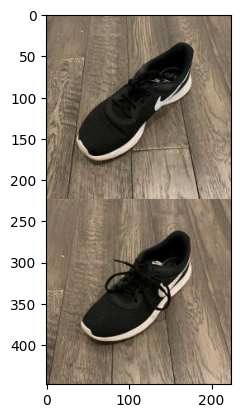

In [ ]:
def generate_same_pair(data):
  """
  Receives data: Numpy array of shape [Triplets, 3, 2, 224, 224, 3]
  Returns Numpy array of shape [Total_Pairs, 448, 224, 3] of a  same pair of
  shoes concatenate together
  """
  # merge triplets and pairs dimentions: (N, 3, ...) --> (N*3, ...):
  # [N * 3, 2, 224, 224, 3]
  total_pairs_shape = data.shape[0] * 3
  reshaped_data = data.reshape(total_pairs_shape, 2, 224, 224, 3)

  # index 0 is the 'right' shoe and 1 is the 'left' shoe
  # both will have the same shape: [Total_Pairs, 224, 224, 3]
  right_shoe = reshaped_data[:, 0, :, :, :]
  left_shoe = reshaped_data[:, 1, :, :, :]

  # concatenate the two images together - total height: 224 + 224 = 448.
  same_pairs_concatenate = np.concatenate((right_shoe, left_shoe), axis=1)
  return same_pairs_concatenate

same_pairs_train = generate_same_pair(train_data)
# if this is [N, 3, 2, 224, 224, 3]
print(f"Original shape: {train_data.shape}")
# should be [N*3, 448, 224, 3] = (285, 448, 224, 3)
print(f"New shape (Same Pairs): {same_pairs_train.shape}")
# should show 2 shoes from the same pair
plt.imshow(generate_same_pair(train_data)[0]+0.5)

### 1.3 Negative Pair Generation

For each triplet, 3 negative pairs are randomly sampled from the 6 possible wrong combinations keeping the dataset balanced between positive and negative examples.

Original shape: (95, 3, 2, 224, 224, 3)
New shape (Diff Pairs): (285, 448, 224, 3)


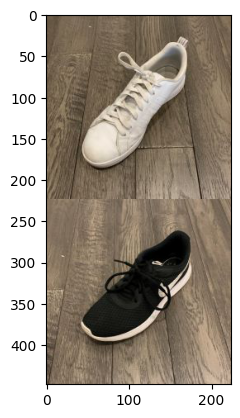

In [ ]:

def generate_different_pair(data):
    """
    Receives data: Numpy array of shape [Triplets, 3, 2, 224, 224, 3]
    Returns Numpy array of shape [Total_Pairs, 448, 224, 3]. Each image will conmtain
    2 shoes from a different pair, but submitted by the same student
    """
    different_pairs_list = []
    triplets_shape = data.shape[0]

    # possible combinations of different pairs :
    # (index of pair A, index of pair B) , A != B
    possible_combinations = [(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]
    possible_combinations_length = len(possible_combinations)
    # create an array of indexes [0, 1, 2, 3, 4, 5] to select from
    combination_indices = np.arange(possible_combinations_length)

    # scan all triplates
    for triplate_index in range(triplets_shape):
        # choose 3 random different combinations from combination_indexes
        chosen_diff_indexes = np.random.choice(combination_indices, size=3, replace=False)
        # scan all 3 random combinations
        for currnent_diff_index in chosen_diff_indexes:
            # extract the indexes of 2 pairs using current_diff_index
            pair1, pair2 = possible_combinations[currnent_diff_index]
            # take 'right' shoe (0) from the first pair
            right = data[triplate_index, pair1, 0, :, :, :]
            # take 'left' shoe (1) from the second pair
            left = data[triplate_index, pair2, 1, :, :, :]
            # concatenate pair - shpae of (448, 224, 3)
            concatenate_image = np.concatenate((right, left), axis=0)
            # save the different pair
            different_pairs_list.append(concatenate_image)
    return np.array(different_pairs_list)


diff_pairs_train = generate_different_pair(train_data)
# if this is [N, 3, 2, 224, 224, 3] = [95, 3, 2, 224, 224, 3]
print(f"Original shape: {train_data.shape}")
# should be [N*3, 448, 224, 3] = (285, 448, 224, 3)
print(f"New shape (Diff Pairs): {diff_pairs_train.shape}")
plt.imshow(generate_different_pair(train_data)[0]+0.5) # should show 2 shoes from different pairs

## 2. Model Architectures

### 2.1 CNN Model

Input: `(N, 3, 448, 224)`, batch of concatenated shoe pairs.

Architecture:
- 4 convolutional blocks: `3->n->2n->4n->8n` channels, each followed by ReLU + 2x2 MaxPool
- Kernel size 5x5, padding = 2
- Fully connected: flatten -> 100 -> 2
- Output: `(N, 2)` - same pair / different pair


### 2.2 CNNChannel Model

Same architecture as CNN, with one key difference: instead of processing the 448x224 concatenated image directly, the input is first split into two 224x224 halves and stacked along the **channel dimension** - resulting in a `(N, 6, 224, 224)` input tensor.

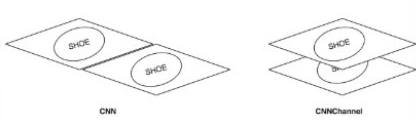

This allows the network to explicitly compare the two shoes at every convolutional layer, rather than learning to split them implicitly.

#### Why CNNChannel Outperforms CNN

In `CNNChannel`, both shoes are stacked along the channel dimension, so each spatial position `(x,y)` contains information from both shoes simultaneously. This allows the convolutional filters to directly compare corresponding pixels from the star, detecting differences in color or texture at the very first layer.

In the standard `CNN`, the two shoes are stacked vertically and separated by a large spatial distance. Early filters (5x5) can only see one shoe at a time, forcing the network to learn the comparison implicitly in deeper layers, making the task harder.

### 2.3 Evaluation

Accuracy is tracked separately for positive (same pair) and negative (different pair) samples. The final score is the average of the two.

In [ ]:
def get_accuracy(model, data, batch_size=50,device='cpu'):
    """Compute the model accuracy on the data set. This function returns two
    separate values: the model accuracy on the positive samples,
    and the model accuracy on the negative samples.

    Example Usage:

    >>> model = CNN() # create untrained model
    >>> pos_acc, neg_acc= get_accuracy(model, valid_data)
    >>> false_positive = 1 - pos_acc
    >>> false_negative = 1 - neg_acc
    """

    model.eval()
    n = data.shape[0]

    data_pos = generate_same_pair(data)      # should have shape [n * 3, 448, 224, 3]
    data_neg = generate_different_pair(data) # should have shape [n * 3, 448, 224, 3]

    pos_correct = 0
    for i in range(0, len(data_pos), batch_size):
        xs = torch.Tensor(data_pos[i:i+batch_size]).permute(0,3,1,2)
        xs = xs.to(device)
        zs = model(xs)
        pred = zs.max(1, keepdim=True)[1] # get the index of the max logit
        pred = pred.detach().cpu().numpy()
        pos_correct += (pred == 1).sum()

    neg_correct = 0
    for i in range(0, len(data_neg), batch_size):
        xs = torch.Tensor(data_neg[i:i+batch_size]).permute(0,3,1,2)
        xs = xs.to(device)
        zs = model(xs)
        pred = zs.max(1, keepdim=True)[1] # get the index of the max logit
        pred = pred.detach().cpu().numpy()
        neg_correct += (pred == 0).sum()

    return pos_correct / (n * 3), neg_correct / (n * 3)

Tracking both metrics separately prevents **model collapse** a scenario where the model achieves a decent overall accuracy by always predicting the majority class. Separate tracking immediately exposes if the model fails entirely on one class.

Additionally, in the context of assisting visually impaired users, the two error types carry different costs: a False Positive (predicting "same pair" when it's not) leads to mismatched shoes, while a False Negative is merely inconvenient.

## 3. Training

### 3.1 Training Loop

- Loss: `CrossEntropyLoss`
- Optimizer: Adam with weight decay
- Each batch: `batch_size/2` positive + `batch_size/2` negative samples, shuffled per epoch
- Tracked per epoch: train accuracy, validation accuracy (positive & negative separately)
- Best model checkpoint saved automatically

In [ ]:
def train_model(model,
                train_data=train_data,
                validation_data=valid_data,
                batch_size=50,
                learning_rate=0.001,
                weight_decay=0,
                epochs=15,
                checkpoint_path=None):
  patience = 8
  epochs_no_improve = 0
  best_val_acc = 0.0

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  # Initialize Loss function and optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # Create the positive and negative pairs
  train_pos_pairs = generate_same_pair(train_data)
  train_neg_pairs = generate_different_pair(train_data)

  val_pos_pairs = generate_same_pair(validation_data)
  val_neg_pairs = generate_different_pair(validation_data)

  train_loss_history = []
  val_acc_history = []
  train_acc_history = []
  val_loss_history = []

  best_val_acc = 0.0

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    train_correct_count = 0
    train_total_count = 0

    # shuffle the positive and negative pairs
    np.random.shuffle(train_pos_pairs)
    np.random.shuffle(train_neg_pairs)

    num_samples = min(len(train_pos_pairs), len(train_neg_pairs))

    for i in range(0,num_samples,batch_size//2):
      # sample batch_size//2 of positive pairs and batch_size//2 of negative pairs
      pos_samples = train_pos_pairs[i : i + batch_size//2]
      neg_samples = train_neg_pairs[i : i + batch_size//2]

      # create the labels of the batch and combine the positive and negative half batches
      pos_labels = np.ones(len(pos_samples))
      neg_labels = np.zeros(len(neg_samples))

      # concatenate data and labels
      inputs_np = np.concatenate((pos_samples, neg_samples), axis=0)
      labels_np = np.concatenate((pos_labels, neg_labels), axis=0)

      # Conversion from numpy array to torch tensor (if working with gpu also change device to gpu)
      # convert to tensor, permute to NCHW format, and move to device
      inputs = torch.tensor(inputs_np).permute(0, 3, 1, 2).float().to(device)
      labels = torch.tensor(labels_np).long().to(device)

      optimizer.zero_grad() # Reset the optimizer
      outputs = model(inputs) # Predict output
      loss = criterion(outputs, labels) # Compute the loss
      loss.backward() # Backward pass
      optimizer.step() # Update the parameters

      running_loss += loss.item() * inputs.size(0) # accumulate batch loss

      prediction_results = torch.max(outputs.data, 1)
      predicted_labels = prediction_results[1] # taking the indices (predictions)

      train_total_count += labels.size(0)
      train_correct_count += (predicted_labels == labels).sum().item()


    # calculate average loss and update history
    epoch_loss = running_loss / (num_samples * 2) # *2 because we took from both pos and neg
    train_loss_history.append(epoch_loss)
    train_acc_percent = (train_correct_count / train_total_count) * 100
    train_acc_history.append(train_acc_percent)


    # track the accuracy and loss of the training and validation
    # calculate validation accuracy
    val_pos, val_neg = get_accuracy(model, validation_data, batch_size=batch_size, device=device)
    val_acc = (val_pos + val_neg) / 2
    val_acc_percent = val_acc * 100
    val_acc_history.append(val_acc_percent)

    model.eval()
    val_running_loss = 0.0
    val_total = 0

    np.random.shuffle(val_pos_pairs)
    np.random.shuffle(val_neg_pairs)
    num_val_samples = min(len(val_pos_pairs), len(val_neg_pairs))

    with torch.no_grad(): # not learning just recording
      for i in range(0, num_val_samples, batch_size//2):
        end_idx = min(i + batch_size//2, len(val_pos_pairs))
        v_pos = val_pos_pairs[i:end_idx]
        v_neg = val_neg_pairs[i:end_idx]

        if len(v_pos) == 0:
          continue

        v_inp = np.concatenate((v_pos, v_neg), axis=0)
        v_lbl = np.concatenate((np.ones(len(v_pos)), np.zeros(len(v_neg))), axis=0)

        v_inp_t = torch.tensor(v_inp).permute(0, 3, 1, 2).float().to(device)
        v_lbl_t = torch.tensor(v_lbl).long().to(device)

        v_out = model(v_inp_t)
        v_loss = criterion(v_out, v_lbl_t)

        val_running_loss += v_loss.item() * v_inp_t.size(0)
        val_total += v_lbl_t.size(0)

    val_epoch_loss = val_running_loss / val_total
    val_loss_history.append(val_epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}: Loss={epoch_loss:.4f} ,Train Acc={train_acc_percent:.2f}% ,Val Loss: {val_epoch_loss:.4f} ,Val Acc={val_acc_percent:.2f}%")
    #print(f"Epoch {epoch+1}: Pos: {val_pos:.2f}, Neg: {val_neg:.2f}")

    # checkpointing + early stopping logic
    if val_acc_percent > best_val_acc:
        best_val_acc = val_acc_percent
        epochs_no_improve = 0

        if checkpoint_path is not None:
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  --> NEW RECORD! Model saved (Acc: {best_val_acc:.2f}%)")
    else:
        epochs_no_improve += 1
        print(f"  --> No improvement patience: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print("early stopping triggered (Accuracy didn't improve).")
            break
  return model, train_loss_history, val_acc_history, train_acc_history

### 3.2 Sanity Check

Verified model convergence by overfitting on a small subset (5 images) both models reached 90%+ training accuracy within ~30 iterations.


1. Training CNNChannel...
Epoch 1/30: Loss=0.7143 ,Train Acc=50.00% ,Val Loss: 0.6905 ,Val Acc=58.33%
Epoch 2/30: Loss=0.6618 ,Train Acc=52.78% ,Val Loss: 0.6104 ,Val Acc=69.44%
Epoch 3/30: Loss=0.6175 ,Train Acc=66.67% ,Val Loss: 0.5718 ,Val Acc=72.22%
Epoch 4/30: Loss=0.5396 ,Train Acc=72.22% ,Val Loss: 0.5296 ,Val Acc=75.00%
Epoch 5/30: Loss=0.4654 ,Train Acc=77.78% ,Val Loss: 0.5694 ,Val Acc=66.67%
  --> No improvement patience: 1/8
Epoch 6/30: Loss=0.4259 ,Train Acc=80.56% ,Val Loss: 0.7273 ,Val Acc=72.22%
  --> No improvement patience: 2/8
Epoch 7/30: Loss=0.7205 ,Train Acc=66.67% ,Val Loss: 0.5185 ,Val Acc=72.22%
  --> No improvement patience: 3/8
Epoch 8/30: Loss=0.4491 ,Train Acc=86.11% ,Val Loss: 0.4004 ,Val Acc=83.33%
Epoch 9/30: Loss=0.3253 ,Train Acc=86.11% ,Val Loss: 0.3283 ,Val Acc=91.67%
Epoch 10/30: Loss=0.3484 ,Train Acc=86.11% ,Val Loss: 0.3185 ,Val Acc=86.11%
  --> No improvement patience: 1/8
Epoch 11/30: Loss=0.2889 ,Train Acc=88.89% ,Val Loss: 0.3323 ,Val Acc=91

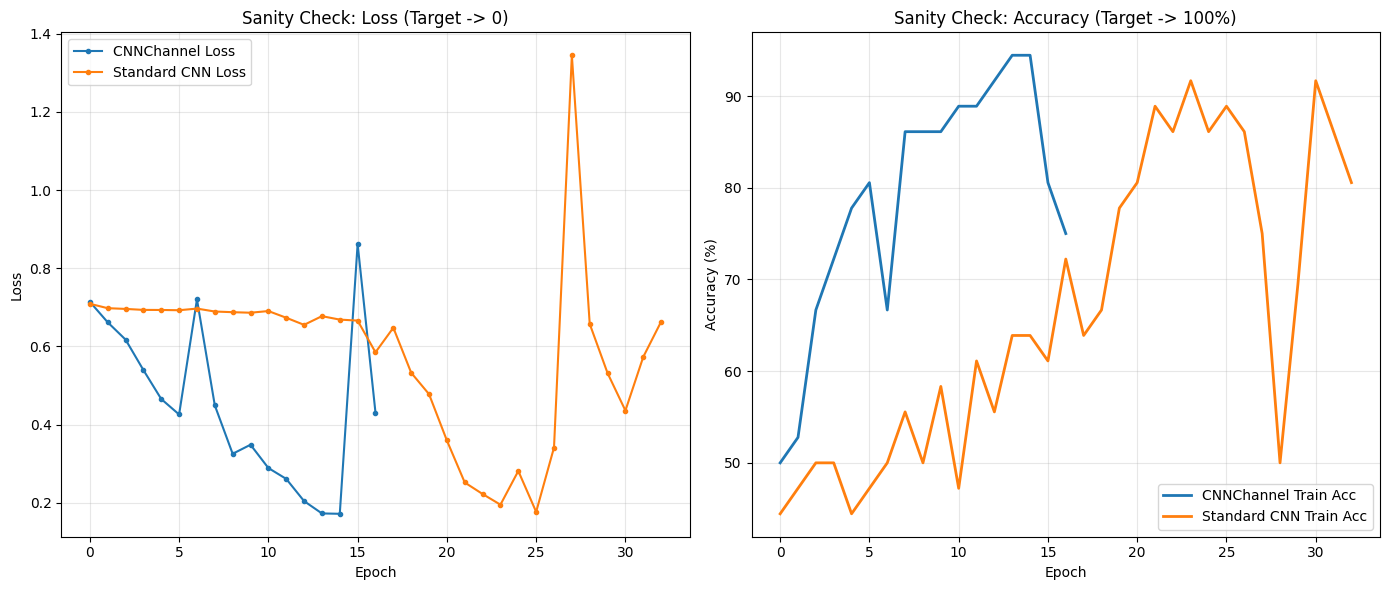

In [ ]:
reload_functions()
import ML_DL_Functions3
# using 6 samples to ensure we have enough for batch_size=5
small_data = train_data[10:16]

# Train CNNChannel
print("\n1. Training CNNChannel...")
model_channel = ML_DL_Functions3.CNNChannel()

model_channel, loss_channel, val_acc_channel, train_acc_channel = train_model(
    model=model_channel,
    train_data=small_data,
    validation_data=small_data,
    batch_size=5,
    learning_rate=0.001,
    epochs=30,
    checkpoint_path=None
)

# Train Standard CNN
print("\n2. Training Standard CNN...")
model_cnn = ML_DL_Functions3.CNN()

model_cnn, loss_cnn, val_acc_cnn, train_acc_cnn = train_model(
    model=model_cnn,
    train_data=small_data,
    validation_data=small_data,
    batch_size=5,
    learning_rate=0.0005,
    epochs=50,
    checkpoint_path=None
)


print("\n" + "="*30)
print("FINAL RESULTS (Sanity Check)")
print("="*30)

best_channel_acc = max(val_acc_channel)
best_standard_acc = max(val_acc_cnn)

print(f"CNNChannel Best Acc:  {best_channel_acc:.2f}%")
print(f"Standard CNN Best Acc: {best_standard_acc:.2f}%")

print("="*30)

# Plotting results
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(loss_channel, label='CNNChannel Loss', marker='.')
plt.plot(loss_cnn, label='Standard CNN Loss', marker='.')
plt.title('Sanity Check: Loss (Target -> 0)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_acc_channel, label='CNNChannel Train Acc', linewidth=2)
plt.plot(train_acc_cnn, label='Standard CNN Train Acc', linewidth=2)

plt.title('Sanity Check: Accuracy (Target -> 100%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### 3.3 Hyperparameter Tuning & Final Models

Key hyperparameters explored: learning rate, batch size, `n` (base channels), kernel size.
Best model checkpoint selected based on validation accuracy.

| Model | Parameters | Best Val Accuracy |
|-------|-----------|------------------|
| CNN | 11.1M | 77.45% |
| CNNChannel | 6.1M | **88.24%** |

CNNChannel outperformed the standard CNN by ~11%, confirming that channel-wise concatenation is a more effective approach for pairwise shoe comparison.


--- 1. Training CNN Channel ---
Epoch 1/60: Loss=0.6916 ,Train Acc=52.81% ,Val Loss: 0.6797 ,Val Acc=54.90%
  --> NEW RECORD! Model saved (Acc: 54.90%)
Epoch 2/60: Loss=0.6425 ,Train Acc=67.19% ,Val Loss: 0.5549 ,Val Acc=73.53%
  --> NEW RECORD! Model saved (Acc: 73.53%)
Epoch 3/60: Loss=0.5523 ,Train Acc=71.40% ,Val Loss: 0.5355 ,Val Acc=64.71%
  --> No improvement patience: 1/8
Epoch 4/60: Loss=0.4835 ,Train Acc=75.61% ,Val Loss: 0.4350 ,Val Acc=77.45%
  --> NEW RECORD! Model saved (Acc: 77.45%)
Epoch 5/60: Loss=0.4440 ,Train Acc=81.58% ,Val Loss: 0.4257 ,Val Acc=80.39%
  --> NEW RECORD! Model saved (Acc: 80.39%)
Epoch 6/60: Loss=0.4141 ,Train Acc=81.75% ,Val Loss: 0.3881 ,Val Acc=88.24%
  --> NEW RECORD! Model saved (Acc: 88.24%)
Epoch 7/60: Loss=0.3961 ,Train Acc=82.28% ,Val Loss: 0.4391 ,Val Acc=78.43%
  --> No improvement patience: 1/8
Epoch 8/60: Loss=0.3914 ,Train Acc=83.86% ,Val Loss: 0.3775 ,Val Acc=85.29%
  --> No improvement patience: 2/8
Epoch 9/60: Loss=0.3760 ,Train Acc

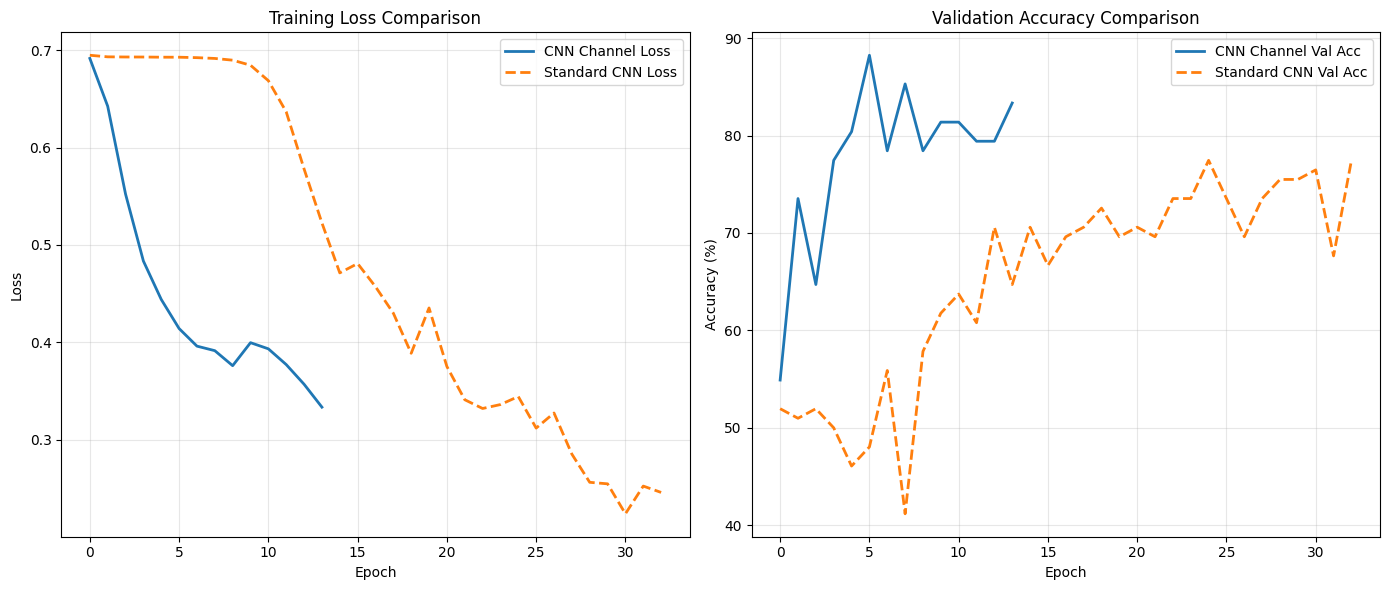

In [ ]:
reload_functions()
import ML_DL_Functions3
# ==========================================
# Training CNN Channel (Model A)
print("\n--- 1. Training CNN Channel ---")
CNNChannel_model = ML_DL_Functions3.CNNChannel()
path_channel = "best_cnn_channel.pth"

# training with tuned parameters for Channel
CNNChannel_model, loss_ch, val_acc_ch, train_acc_ch = train_model(
    model=CNNChannel_model,
    train_data=train_data,
    validation_data=valid_data,
    batch_size=64,
    learning_rate=0.0001,
    epochs=60,
    weight_decay=0.0001,
    checkpoint_path=path_channel
)


# Training Standard CNN (Model B)
print("\n--- 2. Training Standard CNN ---")
CNN_model = ML_DL_Functions3.CNN()
path_cnn = "best_standard_cnn.pth"

# Training with standard parameters
CNN_model, loss_cnn, val_acc_cnn, train_acc_cnn = train_model(
    model=CNN_model,
    train_data=train_data,
    validation_data=valid_data,
    batch_size=32,
    learning_rate=0.00005,
    epochs=50,
    weight_decay=0.001,
    checkpoint_path=path_cnn
)

# Final Visualization
best_ch_score = max(val_acc_ch)
best_cnn_score = max(val_acc_cnn)

print("\n" + "="*30)
print("FINAL RESULTS (Best Validation Accuracy)")
print(f"CNN Channel Best Acc:  {best_ch_score:.2f}%")
print(f"Standard CNN Best Acc: {best_cnn_score:.2f}%")

if best_ch_score > best_cnn_score:
    print(f"WINNER: CNN Channel (Saved to {path_channel})")
else:
    print(f"WINNER: Standard CNN (Saved to {path_cnn})")
print("="*30)

# Plotting results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(loss_ch, label='CNN Channel Loss', linewidth=2)
plt.plot(loss_cnn, label='Standard CNN Loss', linewidth=2, linestyle='--')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_acc_ch, label='CNN Channel Val Acc', linewidth=2)
plt.plot(val_acc_cnn, label='Standard CNN Val Acc', linewidth=2, linestyle='--')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
checkpoint_path  = drive_path+"checkpoints/" 
torch.save(CNN_model.state_dict(), checkpoint_path+"best_CNN_model.pk") 
torch.save(CNNChannel_model.state_dict(), checkpoint_path+"best_CNNChannel_model.pk") 

## 4. Results

### 4.1 Test Accuracies

Final evaluation of the best model (CNNChannel) on both test sets:

| Test Set | Positive Acc | Negative Acc | Average |
|----------|-------------|--------------|---------|
| Women's shoes (`test_w`) | 90.00% | 76.67% | **83.33%** |
| Men's shoes (`test_m`) | 73.33% | 90.00% | **81.67%** |

In [ ]:
reload_functions()
import ML_DL_Functions3
# Write your code here.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = ML_DL_Functions3.CNNChannel()
best_model.load_state_dict(
    torch.load(drive_path + "checkpoints/best_CNNChannel_model.pk",
               map_location=device)
)
best_model.to(device)
best_model.eval()

print("Loaded best model: CNNChannel (based on validation accuracy)")


# Men
pos_m, neg_m = get_accuracy(best_model, test_m_data, batch_size=64, device=device)
print(f"\nMen's Results:   Pos: {pos_m:.2%} | Neg: {neg_m:.2%} | Avg: {(pos_m + neg_m) / 2:.2%}")

# Women
pos_w, neg_w = get_accuracy(best_model, test_w_data, batch_size=64, device=device)
print(f"Women's Results: Pos: {pos_w:.2%} | Neg: {neg_w:.2%} | Avg: {(pos_w + neg_w) / 2:.2%}")

Loaded best model: CNNChannel (based on validation accuracy)

Men's Results:   Pos: 73.33% | Neg: 90.00% | Avg: 81.67%
Women's Results: Pos: 90.00% | Neg: 76.67% | Avg: 83.33%


### 4.2 Men's Shoes example



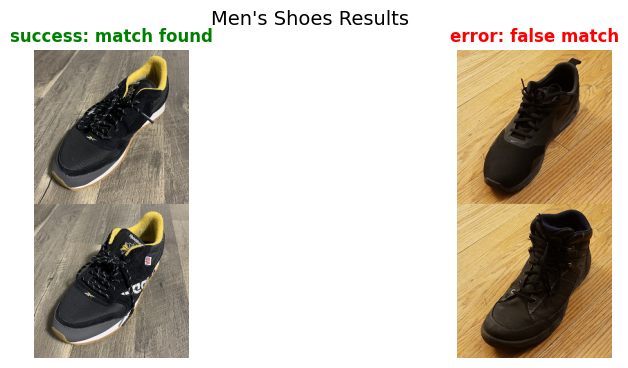

In [ ]:
def show_examples(data, title):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  # prepare data subsets
  same_pairs = generate_same_pair(data)[:100]
  diff_pairs = generate_different_pair(data)[:100]
  # find a SUCCESS
  inputs_same = torch.tensor(same_pairs).permute(0, 3, 1, 2).float().to(device)
  preds_same = best_model(inputs_same).argmax(dim=1)
  correct_idx = (preds_same == 1).nonzero(as_tuple=True)[0]

  # find a MISTAKE
  inputs_diff = torch.tensor(diff_pairs).permute(0, 3, 1, 2).float().to(device)
  preds_diff = best_model(inputs_diff).argmax(dim=1)
  wrong_idx = (preds_diff == 1).nonzero(as_tuple=True)[0]
  # plot results
  plt.figure(figsize=(10, 4))
  plt.suptitle(title, fontsize=14)
  # plot Success
  plt.subplot(1, 2, 1)
  if len(correct_idx) > 0:
      plt.imshow(same_pairs[correct_idx[0].item()] + 0.5)
      plt.title("success: match found", color='green', fontweight='bold')
  else:
      # Fallback if model is too good
      plt.text(0.5, 0.5, "No correct examples", ha='center')
  plt.axis('off')
  # plot mistake
  plt.subplot(1, 2, 2)
  if len(wrong_idx) > 0:
      plt.imshow(diff_pairs[wrong_idx[0].item()] + 0.5)
      plt.title("error: false match", color='red', fontweight='bold')
  else:
      # fallback if model is too good
      inputs_same = torch.tensor(same_pairs).permute(0, 3, 1, 2).float().to(device)
      preds_same = best_model(inputs_same).argmax(dim=1)
      missed_idx = (preds_same == 0).nonzero(as_tuple=True)[0]
      if len(missed_idx) > 0:
            plt.imshow(same_pairs[missed_idx[0].item()] + 0.5)
            plt.title("error: missed match", color='red', fontweight='bold')
      else:
            plt.text(0.5, 0.5, "perfect model!", ha='center')

  plt.axis('off')
  plt.show()


show_examples(test_m_data, "Men's Shoes Results")


### 4.2 Women's Shoes example


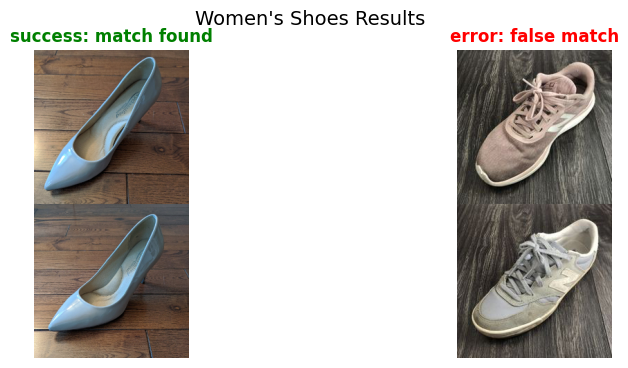

In [ ]:
show_examples(test_w_data, "Women's Shoes Results")

## Credits

Implemented by **Asaf Schreiber** and **Shachar Lavi** as part of the *Introduction to Machine Learning* course at **Ben-Gurion University of the Negev**, instructed by **Dr. Nir Shalzinger**.

The assignment framework and dataset were provided by the course staff.